In [ ]:
!pip install osmnx networkx

In [ ]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [4]:
def to_undirected_multigraph(G):
    """
    Converte um MultiDiGraph direcionado em um MultiGraph não-direcionado,
    preservando atributos dos nós e arestas.
    """
    H = nx.MultiGraph()
    for n, data in G.nodes(data=True):
        H.add_node(n, **data)
    for u, v, data in G.edges(data=True):
        H.add_edge(u, v, **data)
    H.graph.update(G.graph)
    return H

In [6]:
def process_city_mst(place):
    """
    Processa uma cidade, calcula MST entre universidades e retorna dados e figura.
    """
    try:
        print(f"\nProcessando: {place}")

        # 1. Obter o grafo da cidade
        G = ox.graph_from_place(place, network_type='drive')
        G_undirected = to_undirected_multigraph(G)

        # 2. Obter POIs (universidades)
        tags = {'amenity': 'university'}
        pois = ox.features.features_from_place(place, tags=tags)

        university_points = []
        for idx, row in pois.iterrows():
            if row.geometry.geom_type == 'Point':
                university_points.append((row.geometry.y, row.geometry.x))
            else:
                university_points.append((row.geometry.centroid.y, row.geometry.centroid.x))

        # Fallback para escolas se não encontrar universidades
        if not university_points:
            print(f"  Nenhuma universidade encontrada. Tentando escolas...")
            tags = {'amenity': 'school'}
            pois = ox.features.features_from_place(place, tags=tags)
            for idx, row in pois.iterrows():
                if row.geometry.geom_type == 'Point':
                    university_points.append((row.geometry.y, row.geometry.x))
                else:
                    university_points.append((row.geometry.centroid.y, row.geometry.centroid.x))

        if len(university_points) < 2:
            print(f"  AVISO: POIs insuficientes (<2) para {place}")
            return None

        # 3. Encontrar nós mais próximos dos POIs
        latitudes = [hp[0] for hp in university_points]
        longitudes = [hp[1] for hp in university_points]
        university_nodes = ox.distance.nearest_nodes(G_undirected, X=longitudes, Y=latitudes)
        university_nodes = list(set(university_nodes))

        num_pois = len(university_nodes)
        print(f"  POIs encontrados: {num_pois}")

        if num_pois < 2:
            print(f"  AVISO: POIs únicos insuficientes (<2)")
            return None

        # 4. Construir grafo completo com menor rota entre POIs
        G_interest = nx.Graph()
        for i in range(len(university_nodes)):
            for j in range(i+1, len(university_nodes)):
                try:
                    route = nx.astar_path(
                        G_undirected,
                        university_nodes[i],
                        university_nodes[j],
                        heuristic=lambda u, v: abs(G.nodes[u]['x'] - G.nodes[v]['x']) + abs(G.nodes[u]['y'] - G.nodes[v]['y']),
                        weight='length'
                    )
                    route_length = 0
                    for k in range(len(route)-1):
                        route_length += G_undirected[route[k]][route[k+1]][0]['length']
                    G_interest.add_edge(university_nodes[i], university_nodes[j], weight=route_length)
                except:
                    print(f"    Rota não encontrada entre POIs {i} e {j}")
                    continue

        if G_interest.number_of_edges() == 0:
            print(f"  AVISO: Nenhuma rota válida encontrada")
            return None

        # 5. Calcular o MST
        mst_edges = list(nx.minimum_spanning_edges(G_interest, data=True))
        total_mst_length = sum([d['weight'] for (u, v, d) in mst_edges])
        num_edges = len(mst_edges)

        print(f"  MST: {total_mst_length/1000:.2f} km com {num_edges} arestas")

        # Calcular rotas do MST
        mst_routes = []
        for (u, v, d) in mst_edges:
            try:
                route = nx.astar_path(
                    G_undirected,
                    u,
                    v,
                    heuristic=lambda u, v: abs(G.nodes[u]['x'] - G.nodes[v]['x']) + abs(G.nodes[u]['y'] - G.nodes[v]['y']),
                    weight='length'
                )
                mst_routes.append(route)
            except:
                continue

        city_name = place.split(',')[0]

        # Retornar dados necessários para plotagem
        return {
            'cidade': city_name,
            'num_pois': num_pois,
            'mst_length_km': total_mst_length / 1000,
            'num_edges': num_edges,
            'avg_per_poi': (total_mst_length / 1000) / num_pois if num_pois > 0 else 0,
            'avg_per_edge': (total_mst_length / 1000) / num_edges if num_edges > 0 else 0,
            'G_undirected': G_undirected, # Retorna o grafo para plotagem
            'university_nodes': university_nodes, # Retorna os nós dos POIs
            'mst_routes': mst_routes # Retorna as rotas do MST
        }

    except Exception as e:
        print(f"  ERRO ao processar {place}: {str(e)}")
        return None

In [22]:
# Lista das 9 capitais do Nordeste
capitais_nordeste = [
    "São Luís, Maranhão, Brazil",
    "Teresina, Piauí, Brazil",
    "Fortaleza, Ceará, Brazil",
    "Natal, Rio Grande do Norte, Brazil",
    "João Pessoa, Paraíba, Brazil",
    "Recife, Pernambuco, Brazil",
    "Maceió, Alagoas, Brazil",
    "Aracaju, Sergipe, Brazil",
    "Salvador, Bahia, Brazil"
]

In [23]:
# Processar todas as cidades
results = []
for city in capitais_nordeste:
    result = process_city_mst(city)
    if result is not None:
        results.append(result)

print(f"Processamento concluído: {len(results)}/{len(capitais_nordeste)} cidades")


Processando: São Luís, Maranhão, Brazil
  POIs encontrados: 26
  MST: 39.61 km com 25 arestas

Processando: Teresina, Piauí, Brazil
  POIs encontrados: 33
  MST: 40.41 km com 32 arestas

Processando: Fortaleza, Ceará, Brazil
  POIs encontrados: 63
  MST: 62.07 km com 62 arestas

Processando: Natal, Rio Grande do Norte, Brazil
  POIs encontrados: 14
  MST: 17.64 km com 13 arestas

Processando: João Pessoa, Paraíba, Brazil
  POIs encontrados: 12
  MST: 30.49 km com 11 arestas

Processando: Recife, Pernambuco, Brazil
  POIs encontrados: 42
  MST: 47.80 km com 41 arestas

Processando: Maceió, Alagoas, Brazil
  POIs encontrados: 18
  MST: 32.52 km com 17 arestas

Processando: Aracaju, Sergipe, Brazil
  POIs encontrados: 13
  MST: 20.24 km com 12 arestas

Processando: Salvador, Bahia, Brazil
  POIs encontrados: 59
  MST: 70.23 km com 58 arestas
Processamento concluído: 9/9 cidades


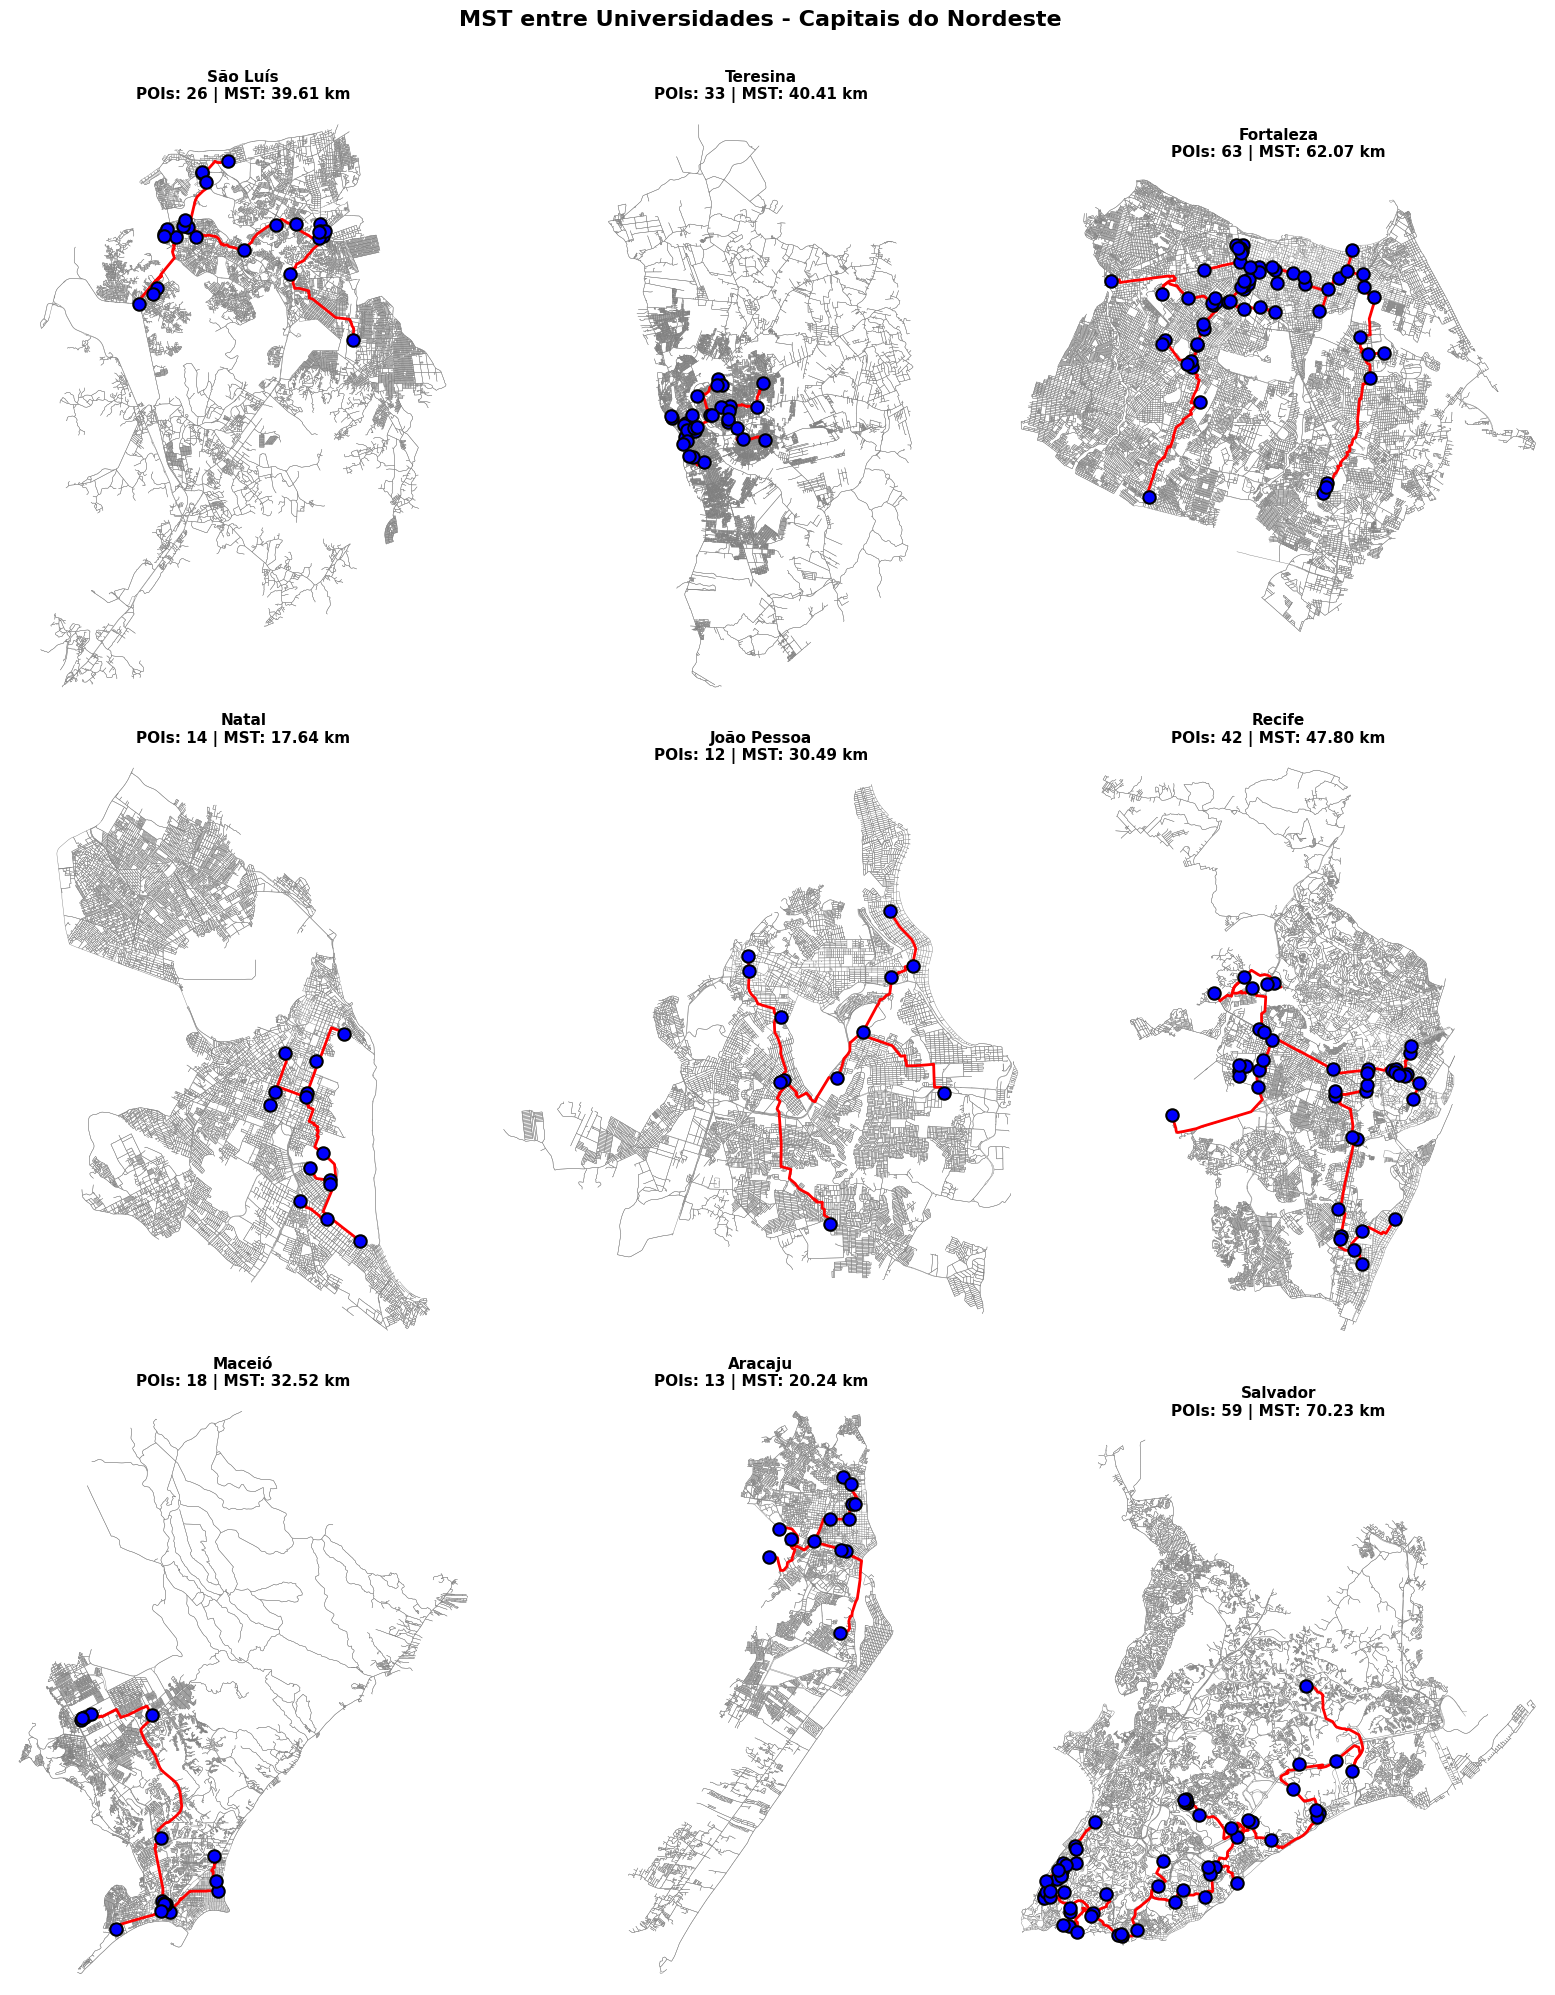

In [ ]:
# CRIAR MATRIZ 3x3 DE GRÁFICOS
fig_combined = plt.figure(figsize=(16, 20))

for idx, result in enumerate(results):
    # Criar subplot na posição correta (3 linhas x 3 colunas)
    ax_combined = plt.subplot(3, 3, idx + 1)

    # Obter os dados de plotagem do resultado
    G_undirected = result['G_undirected']
    mst_routes = result['mst_routes']
    university_nodes = result['university_nodes']

    # Plotar o grafo base no subplot combinado
    ox.plot_graph(
        G_undirected, ax=ax_combined, node_size=0, edge_color="gray",
        edge_linewidth=0.3, show=False, close=False
    )

    # Destacar as rotas do MST em vermelho no subplot combinado
    for route in mst_routes:
        x = [G_undirected.nodes[n]['x'] for n in route]
        y = [G_undirected.nodes[n]['y'] for n in route]
        ax_combined.plot(x, y, color='red', linewidth=2, zorder=4)

    # Plotar também os POIs (universidades) em azul no subplot combinado
    poi_x = [G_undirected.nodes[n]['x'] for n in university_nodes]
    poi_y = [G_undirected.nodes[n]['y'] for n in university_nodes]
    ax_combined.scatter(poi_x, poi_y, c='blue', s=80, zorder=5, edgecolor='black', linewidth=1.5)

    ax_combined.set_aspect('equal')
    ax_combined.axis('off')

    city_name = result['cidade']
    num_pois = result['num_pois']
    mst_km = result['mst_length_km']

    ax_combined.set_title(f"{city_name}\nPOIs: {num_pois} | MST: {mst_km:.2f} km",
                          fontsize=11, fontweight='bold', pad=10)


plt.suptitle('MST entre Universidades - Capitais do Nordeste',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig('graficos/mst_universidades.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# CRIAR TABELA COMPARATIVA
df_results = pd.DataFrame(results)

In [37]:
# Calcular estatísticas
df_results = df_results[['cidade', 'num_pois', 'mst_length_km', 'num_edges', 'avg_per_poi', 'avg_per_edge']]

In [38]:
# Renomear colunas
df_results.columns = [
    'Cidade',
    'Nº POIs',
    'MST Total (km)',
    'Nº Arestas MST',
    'Média por POI (km/POI)',
    'Média por Aresta (km/aresta)'
]

In [39]:
# Adicionar linha de estatísticas globais
stats_row = pd.DataFrame([{
    'Cidade': 'MÉDIA GERAL',
    'Nº POIs': df_results['Nº POIs'].mean(),
    'MST Total (km)': df_results['MST Total (km)'].mean(),
    'Nº Arestas MST': df_results['Nº Arestas MST'].mean(),
    'Média por POI (km/POI)': df_results['Média por POI (km/POI)'].mean(),
    'Média por Aresta (km/aresta)': df_results['Média por Aresta (km/aresta)'].mean()
}])

In [40]:
desvio_row = pd.DataFrame([{
    'Cidade': 'DESVIO PADRÃO',
    'Nº POIs': df_results['Nº POIs'].std(),
    'MST Total (km)': df_results['MST Total (km)'].std(),
    'Nº Arestas MST': df_results['Nº Arestas MST'].std(),
    'Média por POI (km/POI)': df_results['Média por POI (km/POI)'].std(),
    'Média por Aresta (km/aresta)': df_results['Média por Aresta (km/aresta)'].std()
}])

In [41]:
# Ordenar por MST Total
df_results = df_results.sort_values('MST Total (km)', ascending=False)

In [42]:
# Concatenar com estatísticas
df_final = pd.concat([df_results, stats_row, desvio_row], ignore_index=True)

In [43]:
# Formatar números
pd.options.display.float_format = '{:.2f}'.format

In [44]:
print("\n" + "="*100)
print("TABELA COMPARATIVA - MST ENTRE UNIVERSIDADES NAS CAPITAIS DO NORDESTE")
print("="*100)
print(df_final.to_string(index=False))
print("="*100)


TABELA COMPARATIVA - MST ENTRE UNIVERSIDADES NAS CAPITAIS DO NORDESTE
       Cidade  Nº POIs  MST Total (km)  Nº Arestas MST  Média por POI (km/POI)  Média por Aresta (km/aresta)
     Salvador    59.00           70.23           58.00                    1.19                          1.21
    Fortaleza    63.00           62.07           62.00                    0.99                          1.00
       Recife    42.00           47.80           41.00                    1.14                          1.17
     Teresina    33.00           40.41           32.00                    1.22                          1.26
     São Luís    26.00           39.61           25.00                    1.52                          1.58
       Maceió    18.00           32.52           17.00                    1.81                          1.91
  João Pessoa    12.00           30.49           11.00                    2.54                          2.77
      Aracaju    13.00           20.24           12.00   

In [ ]:
# Salvar tabela em CSV
df_final.to_csv('tabela/mst_univercidades.csv', index=False)